Model_Fashion_MNIST(
  (Flatten_fn): Flatten(start_dim=1, end_dim=-1)
  (layer_1): Linear(in_features=784, out_features=16, bias=True)
  (layer_2_left): Linear(in_features=16, out_features=8, bias=True)
  (layer_2_right): Linear(in_features=16, out_features=12, bias=True)
  (layer_3_left): Linear(in_features=8, out_features=8, bias=True)
  (layer_3_right): Linear(in_features=12, out_features=8, bias=True)
  (out_layer): Linear(in_features=16, out_features=10, bias=True)
)
starting the training of the model
Epoch No :1 Train Loss :0.0287 | Train Accuracy :70.47%
Epoch No :1 Val Loss :0.0221 | Val Accuracy :76.76%
Epoch No :2 Train Loss :0.0217 | Train Accuracy :77.16%
Epoch No :2 Val Loss :0.0203 | Val Accuracy :78.39%
Epoch No :3 Train Loss :0.0205 | Train Accuracy :78.33%
Epoch No :3 Val Loss :0.0197 | Val Accuracy :79.12%
Epoch No :4 Train Loss :0.0197 | Train Accuracy :78.87%
Epoch No :4 Val Loss :0.0193 | Val Accuracy :79.32%
Epoch No :5 Train Loss :0.0193 | Train Accuracy :79.24%


/tmp/ipykernel_503/3151715812.py:112: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,0].legend()
/tmp/ipykernel_503/3151715812.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()
/tmp/ipykernel_503/3151715812.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1,0].legend()


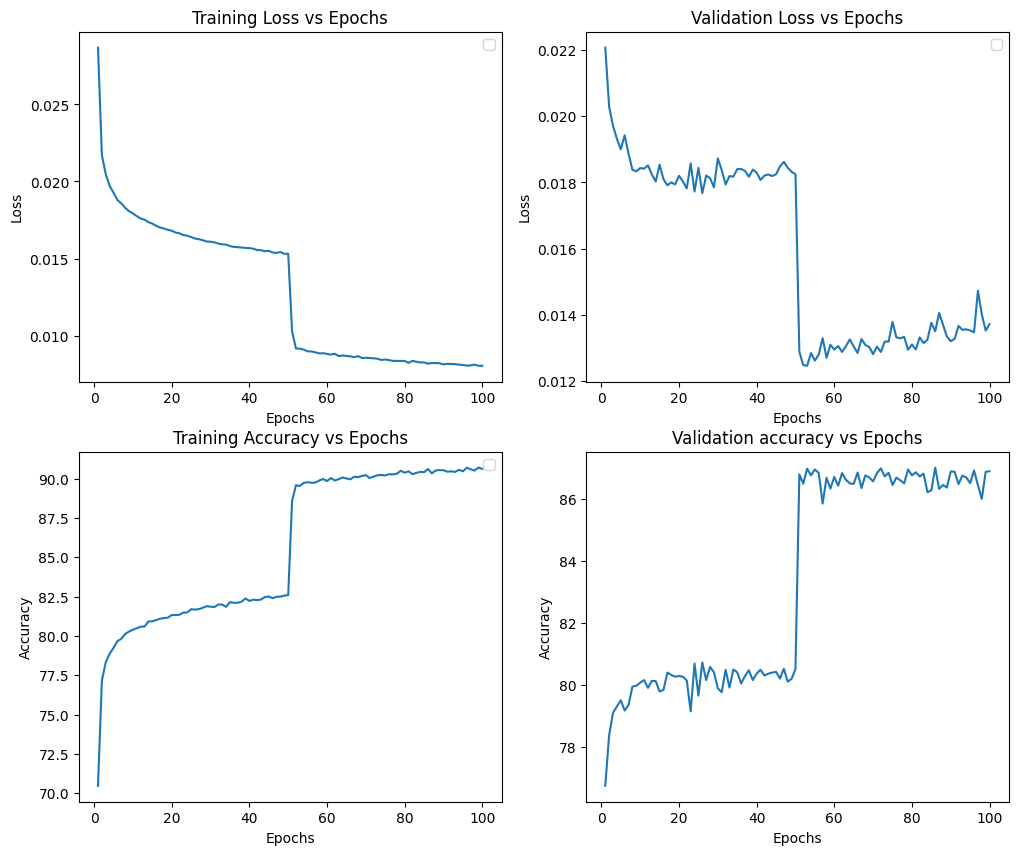

Model weights saved to model_weights.pkl
Test predictions saved to Submissions.csv


In [7]:
import torch
from torch import nn
from torch.utils.data import DataLoader,random_split
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import pickle
import pandas as pd
# device agnostic code
torch.manual_seed(42)
torch.cuda.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
class Model_Fashion_MNIST(nn.Module):
  def __init__(self):
    super().__init__() #to inherit the the methods of the parent nn.Module class
    input_layer=nn.Linear(28,28)
    self.Flatten_fn=nn.Flatten() #to flatten a 28x28 dimension into a 784
    self.layer_1=nn.Linear(784,16) # formation of the first hidden layer
    self.layer_2_left=nn.Linear(16,8) #formation of the hidden layer on the left first
    self.layer_2_right=nn.Linear(16,12) # foramtion of the hidden layer on the right first
    self.layer_3_left=nn.Linear(8,8) # formation of the hidden layer on the left 2nd
    self.layer_3_right=nn.Linear(12,8) #formation of the hidden layer on the right 2nd
    self.out_layer=nn.Linear(16,10) #formation of the final output layer
  def forward(self,x): # every time forward function should be overrided as its there in the prent nn.Module class
    x=self.Flatten_fn(x) #flatten the input data to reduce the dimensions
    x=torch.relu(self.layer_1(x)) #passing through the first hidden layer
    x1=torch.relu(self.layer_2_left(x)) #passing the data the left layer with relu actiavtion function
    x2=torch.relu(self.layer_2_right(x)) #passing the data through the right layer with the relu actiavtion function
    x1_1=torch.relu(self.layer_3_left(x1))# passing the data through the left second layer but using a new variable as there is skip add connection behind
    x2=torch.relu(self.layer_3_right(x2)) # passing through the 2 nd layer on the left side
    x=torch.cat((x1+x1_1,x2),dim=1) #adding the left and right part (concatination)
    x=torch.relu(self.out_layer(x))# passing the merged left and right oart as the input for the final output layer and getting the output
    return x
#creating our model
model=Model_Fashion_MNIST()
model=model.to(device) #transferring the model to the GPU
print(model)
#Fetching the data
train_data = datasets.FashionMNIST(
    root="data", # where to save the data the folder directory
    train=True, #downloading the training dataset
    download=True, #Yes the data has to be downloaded
    transform=ToTensor(), #For the model to be trained using pytorch the the should be coverted to tensors
    target_transform=None,
)
test_data = datasets.FashionMNIST(
    root="data", # similarly as the above but testing data
    train=False,
    download=True,
    transform=ToTensor(),
)
BATCH_SIZE=32 #python cannot take all the data at a single time so it has divided into batches ,here we sought to use 32 datas per iteration
total_size=len(train_data)
train,val=random_split(train_data,[int(total_size*0.8),int(total_size*0.2)]) #splitting the training and the validation data randomly
train=DataLoader(train,shuffle=True,batch_size=BATCH_SIZE) #turning the data into python iterables and shuffling is done to remove like all shirst at once to model
val=DataLoader(val,shuffle=False,batch_size=BATCH_SIZE) # turing data in to python iterables and shuffling is not required as its only for evaludation
test=DataLoader(test_data,shuffle=False,batch_size=BATCH_SIZE) # as the data is for testing no shuffling is required
#training the model
optimizer=torch.optim.Adam(params=model.parameters(),lr=0.001) #to obtain the gradient descent we use adam's algorithm for all parameters
loss_fn=nn.CrossEntropyLoss() #the best loss function for multi class classifictaion
print("starting the training of the model")
epochs=100
performace={'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[]} #to store the performances each epoch
for epoch in range(1,epochs+1):
  correct=0
  total=0
  running_loss=0
  model.train() # setting the model to the training mode
  for batch,(X,y) in enumerate(train):
    X=X.to(device) #trannsfering the input to gpu
    y=y.to(device)
    y_pred=model(X) #finding model output
    loss=loss_fn(y_pred,y) #finding the loss of the model
    optimizer.zero_grad() # deleting previous gradients
    loss.backward() #performing backprobagation and stores data required for updating the gradients
    optimizer.step() # using the adam's algorithm the gradients are updated
    running_loss+=loss.item() # for each iteration in the batch adding the loss
    total+=y.size(0) #finding total no of samples
    correct+= (y_pred.argmax(dim=1) == y).sum().item() # adding if the prediction is correct
  epoch_train_loss=running_loss/total #finding loss per epoch
  epoch_train_acc=(correct/total)*100 #finding accuracy epoch
  performace['train_loss'].append(epoch_train_loss) #appending data at the end opf ech epoch
  performace['train_acc'].append(epoch_train_acc) #appending data at the end of each epoch
  print(f"Epoch No :{epoch} Train Loss :{round(epoch_train_loss,4)} | Train Accuracy :{round(epoch_train_acc,2)}%")
  model.eval() # setting the model to the evaluation mode

  correct=0
  total=0
  running_loss=0
  with torch.inference_mode(): #turns of gradient tracting as the gradient evaluation is not required is required in this part this helps in faster running of the code
    for batch,(X,y) in enumerate(val):
      X=X.to(device)
      y=y.to(device)
      y_pred=model(X)
      loss=loss_fn(y_pred,y)
      running_loss+=loss.item()
      total+=y.size(0)
      correct+= (y_pred.argmax(dim=1) == y).sum().item()
  epoch_val_loss=running_loss/len(val.dataset)
  epoch_val_acc=(correct/total)*100
  performace['val_loss'].append(epoch_val_loss)
  performace['val_acc'].append(epoch_val_acc)
  print(f"Epoch No :{epoch} Val Loss :{round(epoch_val_loss,4)} | Val Accuracy :{round(epoch_val_acc,2)}%")
print("model is trained and validated")
#plotting graph of validation graph vs accuracy
fig,axes=plt.subplots(nrows=2,ncols=2,figsize=(12,10))

axes[0,0].plot(range(1,epoch+1),performace['train_loss'])
axes[0,0].set_xlabel('Epochs')
axes[0,0].set_ylabel('Loss')
axes[0,0].set_title("Training Loss vs Epochs")
axes[0,0].legend()
axes[0,1].plot(range(1,epochs+1),performace['val_loss'])
axes[0,1].set_xlabel('Epochs')
axes[0,1].set_ylabel('Loss')
axes[0,1].set_title("Validation Loss vs Epochs")
axes[0,1].legend()
axes[1,0].plot(range(1,epochs+1),performace['train_acc'])
axes[1,0].set_xlabel('Epochs')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].set_title("Training Accuracy vs Epochs")
axes[1,0].legend()
axes[1,1].plot(range(1,epochs+1),performace['val_acc'])
axes[1,1].set_xlabel('Epochs')
axes[1,1].set_ylabel('Accuracy')
axes[1,1].set_title("Validation accuracy vs Epochs")
plt.show()
#testing of the model
model_weights={k: v.cpu() for k,v in model.state_dict().items()}
with open('model_weights.pkl', 'wb') as f:
    pickle.dump(model_weights, f)
    print("Model weights saved to model_weights.pkl")
    f.close()
model.eval()
with torch.inference_mode():
  test_predictions=[]
  for batch,(X,y) in enumerate(test):
    X=X.to(device)
    y=y.to(device)
    y_pred=model(X)
    test_predictions.extend(y_pred.argmax(dim=1).cpu().numpy()) #the data to be used on list should be a form of numpy top do that we first move to cpu then covert to numpy
test_ids=list(range(len(test_predictions)))
predictions=pd.DataFrame({'ID':test_ids,'Labels':test_predictions})
predictions.to_csv('Submissions.csv',index=False)
print("Test predictions saved to Submissions.csv")